# Fase 4 — Detecção de Anomalias: Candidatos a Deputado Federal Nordeste 2026 (TSE)

## Pergunta de negócio

> **Existem candidatos a Deputado Federal no Nordeste com um perfil claramente atípico — seja em relação a toda a base, seja em relação ao grupo (cluster) a que pertencem?**

Investigamos duas dimensões complementares de atipicidade:

1. **Anomalia global** — esse candidato foge do padrão dos 2.189 candidatos do Nordeste nas 4 dimensões (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`), independentemente do cluster?
2. **Anomalia local (dentro do cluster)** — esse candidato foge do padrão do **seu próprio grupo**? Um candidato pode parecer típico na visão global, mas destoar fortemente dentro dos **Estruturados** (ex.: gastou R$ 47 quando a média do grupo é meio milhão), ou dentro da **Base Simbólica** (ex.: idade incomum ou pequeno gasto registrado).

Consumimos os 4 clusters da Fase 2 (**Estruturados**, **Financiados**, **Base Simbólica**, **Patrimônio Sem Campanha**) e aplicamos o algoritmo **Isolation Forest** (Liu et al., 2008), que busca diretamente os pontos mais fáceis de isolar no hiperplano de atributos.

## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2/3.


In [1]:
CARGO = "DEPUTADO FEDERAL"   # mesmo valor usado nas Fases 0/1/2/3
UF = ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"]  # 9 estados do Nordeste
ANO_ELEICAO = 2026


## Preparando a base — carregando clusters e variáveis da Fase 2

Carregamos o dataset consolidado `dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv`, que já contém as 4 variáveis-driver e as classificações dos 4 clusters gerados na Fase 2.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import plotly.graph_objects as go

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)

nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

import os
os.makedirs('images/notebook4', exist_ok=True)


Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2224 candidatos, 71 colunas


In [3]:
# Garantia defensiva do mapeamento de anos de estudo
if 'ANOS_ESTUDO' not in df.columns or df['ANOS_ESTUDO'].isna().any():
    ANOS_ESTUDO_POR_GRAU = {
        'ANALFABETO': 0, 'LÊ E ESCREVE': 1, 'ENSINO FUNDAMENTAL INCOMPLETO': 4,
        'ENSINO FUNDAMENTAL COMPLETO': 8, 'ENSINO MÉDIO INCOMPLETO': 9,
        'ENSINO MÉDIO COMPLETO': 11, 'SUPERIOR INCOMPLETO': 13, 'SUPERIOR COMPLETO': 16
    }
    df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)


In [4]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Contratadas_Log']

df_cluster = df.copy().reset_index(drop=True)
print(f"Base para detecção de anomalias: {df_cluster.shape[0]} candidatos (Deputado Federal - Nordeste)")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])
df_cluster[colunas_driver].describe().round(2)


Base para detecção de anomalias: 2224 candidatos (Deputado Federal - Nordeste)


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
count,2224.00,2224.00,2224.00,2224.00
mean,48.12,13.76,7.96,8.21
std,11.75,3.09,6.22,5.37
min,21.00,1.00,0.00,0.00
25%,40.00,11.00,0.00,0.00
50%,48.00,16.00,11.29,10.39
75%,56.00,16.00,13.17,12.44
max,83.00,16.00,18.49,15.00


In [5]:
# Identificação e validação dos 4 clusters da Fase 2
if 'cluster_4v_nome' in df_cluster.columns:
    df_cluster['cluster'] = df_cluster['cluster_4v_nome']
elif 'cluster_v3_nome' in df_cluster.columns:
    df_cluster['cluster'] = df_cluster['cluster_v3_nome']
else:
    km = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10)
    map_v3 = {'A': 'Estruturados', 'B': 'Base Simbólica', 'C': 'Financiados', 'D': 'Patrimônio Sem Campanha'}
    df_cluster['cluster'] = [map_v3[chr(65 + x)] for x in km.fit_predict(X)]

print("Distribuição dos candidatos por Cluster:")
display(df_cluster['cluster'].value_counts().to_frame('Qtd Candidatos'))


Distribuição dos candidatos por Cluster:


,Qtd Candidatos
cluster,
Estruturados,1142
Financiados,453
Base Simbólica,370
Patrimônio Sem Campanha,259


## Isolation Forest: como funciona

Todos os algoritmos das fases anteriores definem "normal" de forma indireta: K-Means olha distância até um centro, DBSCAN olha densidade de vizinhança. O **Isolation Forest** faz a pergunta ao contrário, e de forma bem mais direta: **quão fácil é isolar este ponto do resto, cortando o espaço aleatoriamente?**

A ideia, passo a passo:

1. Constrói várias **árvores de isolamento** (isolation trees). Cada árvore escolhe, em cada nó, uma variável **aleatória** e um ponto de corte **aleatório** entre o mínimo e o máximo daquela variável ali — sem nenhuma lógica de "melhor corte" como numa árvore de decisão comum.
2. Repete o corte recursivamente até que cada ponto fique sozinho numa partição.
3. Pontos **isolados** (poucos e diferentes do resto) tendem a cair sozinhos logo nos primeiros cortes — **caminho curto** da raiz até a folha. Pontos numa região **densa** (muitos vizinhos parecidos) precisam de muito mais cortes até se separarem de todo mundo — **caminho longo**.
4. O **score de anomalia** de cada ponto é a média do comprimento desse caminho em todas as árvores da floresta, normalizada — quanto **menor** o caminho médio, mais anômalo.

Duas vantagens práticas: não precisa calcular distância entre todos os pares de pontos (como DBSCAN/hierárquico), então escala bem; e não assume nenhuma forma pro que é "normal" (nem esférica, como K-Means, nem uma região densa contígua, como DBSCAN).

**O parâmetro `contamination`** é a fração de pontos que vocês **esperam de antemão** que sejam anômalos — é uma suposição de quem está modelando, não algo medido a partir dos dados (mesmo espírito do `k` do K-Means ou do `eps` do DBSCAN: um parâmetro que exige julgamento, não tem uma resposta "correta" automática).

### Vendo com dados fictícios

Como com dado real nunca sabemos de verdade quem é anômalo, geramos aqui uma base fictícia onde **nós** decidimos quem é "normal" (dois grupos bem comportados) e quem é "anômalo" (pontos espalhados aleatoriamente pelo espaço) — aí comparamos com o que o algoritmo encontra sozinho, sem ver esses rótulos.


In [6]:
rng = np.random.default_rng(SEMENTE)

# "normal": dois grupos bem comportados (como se fossem 2 clusters)
normal_1 = rng.normal(loc=[2, 2], scale=0.6, size=(80, 2))
normal_2 = rng.normal(loc=[6, 6], scale=0.6, size=(80, 2))
X_normal_ficticio = np.vstack([normal_1, normal_2])

# "anômalo": pontos espalhados aleatoriamente pelo espaço, longe dos dois grupos
X_anomalo_ficticio = rng.uniform(low=-2, high=10, size=(12, 2))

X_ficticio = np.vstack([X_normal_ficticio, X_anomalo_ficticio])
rotulo_real_ficticio = np.array(['Normal'] * len(X_normal_ficticio) + ['Anômalo (fictício)'] * len(X_anomalo_ficticio))

# contamination = a fração real de anômalos fictícios (aqui podemos "trapacear" porque sabemos)
iso_ficticio = IsolationForest(contamination=len(X_anomalo_ficticio) / len(X_ficticio),
                                random_state=SEMENTE, n_estimators=200)
pred_ficticio = iso_ficticio.fit_predict(X_ficticio)
score_ficticio = iso_ficticio.decision_function(X_ficticio)

print(f"Score médio — Normal: {score_ficticio[rotulo_real_ficticio == 'Normal'].mean():.3f}  |  "
      f"Anômalo: {score_ficticio[rotulo_real_ficticio == 'Anômalo (fictício)'].mean():.3f}")


Score médio — Normal: 0.132  |  Anômalo: -0.092


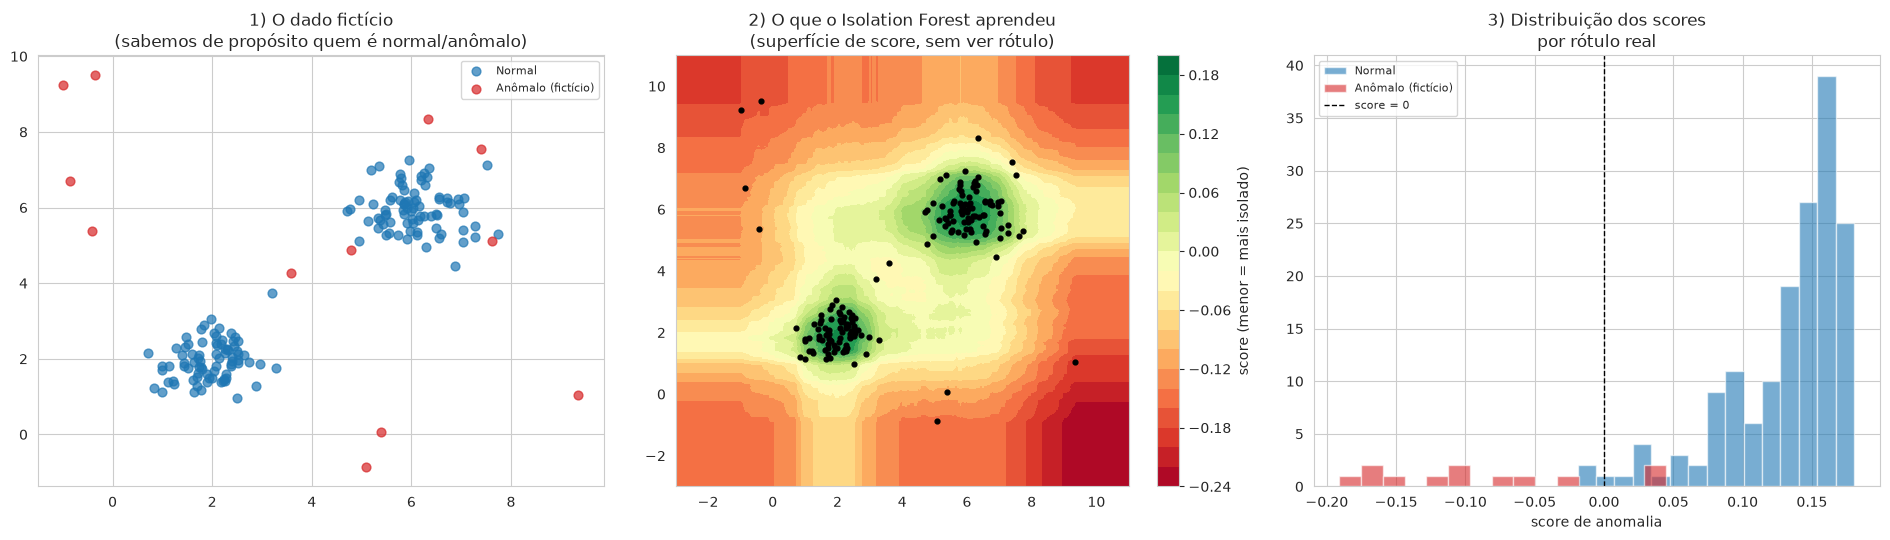

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

cores_ficticio = {'Normal': 'tab:blue', 'Anômalo (fictício)': 'tab:red'}
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[0].scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, label=rotulo, alpha=0.7, s=40)
axes[0].set_title('1) O dado fictício\n(sabemos de propósito quem é normal/anômalo)')
axes[0].legend(fontsize=8)

# superfície de score: o que o algoritmo "enxerga", sem ver rótulo nenhum
xx, yy = np.meshgrid(np.linspace(-3, 11, 300), np.linspace(-3, 11, 300))
Z = iso_ficticio.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlGn')
axes[1].scatter(X_ficticio[:, 0], X_ficticio[:, 1], c='black', s=12)
plt.colorbar(cs, ax=axes[1], label='score (menor = mais isolado)')
axes[1].set_title('2) O que o Isolation Forest aprendeu\n(superfície de score, sem ver rótulo)')

# distribuição dos scores por rótulo real
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[2].hist(score_ficticio[m], bins=15, color=cor, alpha=0.6, label=rotulo)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='score = 0')
axes[2].set_title('3) Distribuição dos scores\npor rótulo real')
axes[2].set_xlabel('score de anomalia')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('images/notebook4/01_intuicao_isolation_forest.png', dpi=300, bbox_inches='tight')
plt.show()


A superfície de score (painel 2) fica **verde** (score alto, "normal") bem em cima dos dois grupos densos, e **vermelha** (score baixo, "anômalo") nas bordas e longe de tudo — exatamente onde estão os pontos fictícios que geramos como "anômalos". O algoritmo nunca viu o rótulo `Normal`/`Anômalo (fictício)`: ele chegou nisso só de contar quão rápido cada ponto fica isolado. O histograma (painel 3) mostra a mesma coisa de outro ângulo: os scores dos pontos normais ficam concentrados bem acima de zero; os anômalos, misturados mais pra baixo — a separação não é perfeita (alguns anômalos fictícios caíram por sorte perto dos grupos densos), o que já é um bom aviso pra quando aplicarmos em dado real: o Isolation Forest não é infalível, é uma sugestão de onde olhar com mais atenção.


### Por dentro de uma única árvore

A superfície de score acima é o resultado **já combinado** de 200 árvores. Pra enxergar o mecanismo de verdade — os cortes aleatórios que dão nome ao algoritmo — olhamos uma árvore sozinha: cada linha abaixo é um corte (variável aleatória, ponto de corte aleatório entre o mínimo e o máximo ali). Escolhemos dois pontos de propósito — um bem no meio de um grupo denso, outro o mais "anômalo" segundo o próprio modelo — e comparamos quantos cortes cada um precisou até ficar sozinho numa partição.


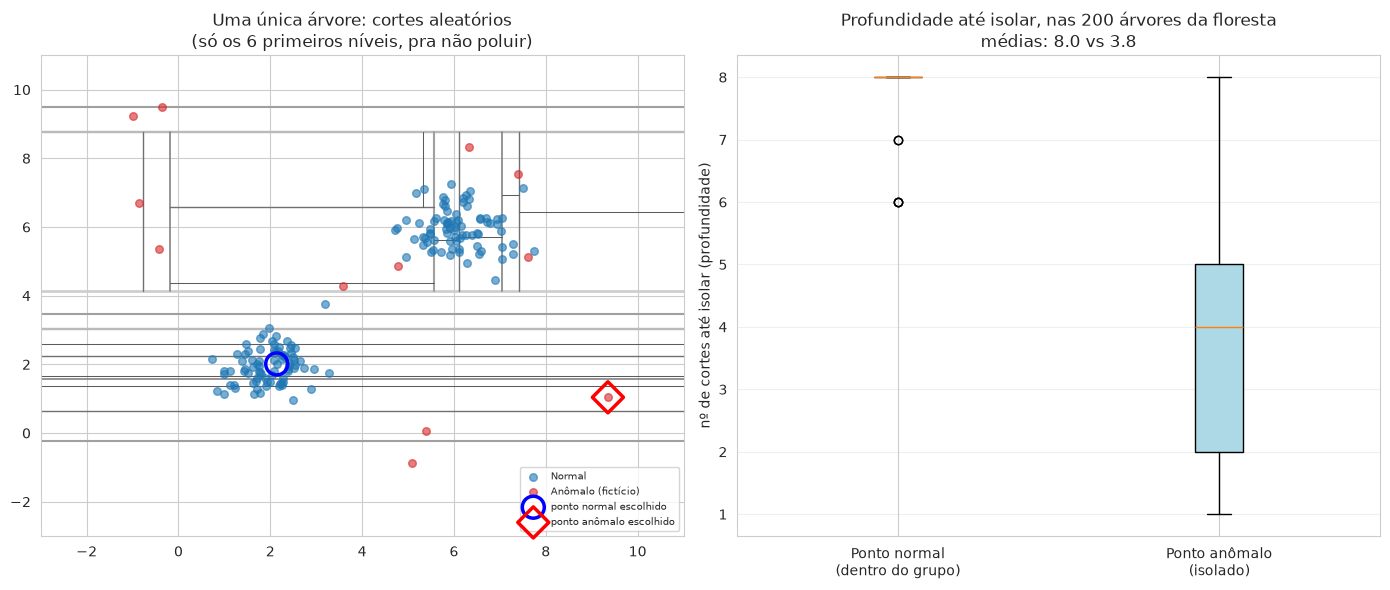

In [8]:
def desenhar_particoes(ax, tree_, no, x_min, x_max, y_min, y_max, profundidade=0, profundidade_max=6):
    """Desenha recursivamente os cortes de uma árvore de isolamento dentro de uma caixa
    [x_min,x_max] x [y_min,y_max]. Só os primeiros `profundidade_max` níveis são desenhados —
    a árvore de verdade continua até isolar cada ponto sozinho, mas isso poluiria demais o
    desenho sem ajudar a entender a ideia."""
    if profundidade >= profundidade_max or tree_.children_left[no] == -1:  # -1 = folha
        return
    variavel, limiar = tree_.feature[no], tree_.threshold[no]
    cor = plt.cm.Greys(0.3 + 0.5 * profundidade / profundidade_max)
    espessura = max(2 - 0.25 * profundidade, 0.4)
    if variavel == 0:
        ax.plot([limiar, limiar], [y_min, y_max], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, limiar, y_min, y_max, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], limiar, x_max, y_min, y_max, profundidade + 1, profundidade_max)
    else:
        ax.plot([x_min, x_max], [limiar, limiar], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, x_max, y_min, limiar, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], x_min, x_max, limiar, y_max, profundidade + 1, profundidade_max)


def profundidade_isolamento(tree_, ponto):
    """Quantos cortes uma árvore precisa até isolar `ponto` sozinho numa folha."""
    no, profundidade = 0, 0
    while tree_.children_left[no] != -1:
        variavel, limiar = tree_.feature[no], tree_.threshold[no]
        no = tree_.children_left[no] if ponto[variavel] <= limiar else tree_.children_right[no]
        profundidade += 1
    return profundidade


# dois pontos escolhidos de propósito: o mais "normal" (mais perto do centro do 1º grupo) e o
# mais "anômalo" de verdade segundo o próprio modelo (menor score entre os pontos fictícios)
ponto_normal = X_normal_ficticio[np.argmin(np.linalg.norm(X_normal_ficticio - [2, 2], axis=1))]
scores_dos_anomalos = iso_ficticio.decision_function(X_anomalo_ficticio)
ponto_anomalo = X_anomalo_ficticio[np.argmin(scores_dos_anomalos)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# painel A: uma única árvore da floresta, cortes desenhados
ax = axes[0]
x_min, x_max, y_min, y_max = -3, 11, -3, 11
uma_arvore = iso_ficticio.estimators_[0].tree_
desenhar_particoes(ax, uma_arvore, 0, x_min, x_max, y_min, y_max)
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    ax.scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, alpha=0.6, s=30, label=rotulo, zorder=3)
ax.scatter(*ponto_normal, s=250, facecolor='none', edgecolor='blue', linewidth=2.5, zorder=4, label='ponto normal escolhido')
ax.scatter(*ponto_anomalo, s=250, facecolor='none', edgecolor='red', linewidth=2.5, marker='D', zorder=4, label='ponto anômalo escolhido')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Uma única árvore: cortes aleatórios\n(só os 6 primeiros níveis, pra não poluir)')
ax.legend(fontsize=7, loc='lower right')

# painel B: profundidade até isolar cada um dos 2 pontos, em TODAS as árvores da floresta
profundidades_normal = [profundidade_isolamento(arv.tree_, ponto_normal) for arv in iso_ficticio.estimators_]
profundidades_anomalo = [profundidade_isolamento(arv.tree_, ponto_anomalo) for arv in iso_ficticio.estimators_]

ax2 = axes[1]
ax2.boxplot([profundidades_normal, profundidades_anomalo],
            tick_labels=['Ponto normal\n(dentro do grupo)', 'Ponto anômalo\n(isolado)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_ylabel('nº de cortes até isolar (profundidade)')
ax2.set_title(f'Profundidade até isolar, nas {len(iso_ficticio.estimators_)} árvores da floresta\n'
              f'médias: {np.mean(profundidades_normal):.1f} vs {np.mean(profundidades_anomalo):.1f}')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/notebook4/02_arvore_cortes_e_profundidade.png', dpi=300, bbox_inches='tight')
plt.show()


No painel A, repare que os cortes se acumulam (linhas mais escuras e grossas, dos primeiros níveis) tentando separar os dois grupos densos um do outro — é preciso *bastante* corte aleatório até isolar alguém que está cercado de vizinhos parecidos. Já nas regiões vazias, um corte já sobra bastante espaço sozinho.

O painel B mostra a consequência disso, com números de verdade: o ponto normal escolhido precisa, em média, de **quase o dobro** de cortes pra ficar isolado, comparado ao ponto anômalo. Repare também que a profundidade **varia bastante de árvore pra árvore** (a caixa do anômalo vai de 1 a 8 cortes) — cada árvore sorteou cortes diferentes, então uma única árvore pode "errar" por sorte. É exatamente por isso que o algoritmo tira a **média de centenas de árvores**, em vez de confiar numa só: no agregado, o padrão (caminho curto = anômalo) se sustenta, mesmo que árvore isolada nenhuma seja confiável sozinha.


---
## Detecção global: quem foge do padrão geral da base?

Reaproveitamos exatamente as mesmas 3 variáveis-driver já padronizadas na Fase 2 (`X`: `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`) — mesma pergunta de negócio, agora olhando pra quem está nas bordas em vez de procurar grupos.

Antes de fixar `contamination`, vale ver como o número de candidatos sinalizados muda conforme a suposição:


In [9]:
for cont in [0.01, 0.02, 0.03, 0.05, 0.08, 'auto']:
    iso_teste = IsolationForest(contamination=cont, random_state=SEMENTE, n_estimators=200)
    pred_teste = iso_teste.fit_predict(X)
    n_atipicos = int((pred_teste == -1).sum())
    print(f"contamination={cont!s:>6}: {n_atipicos:3d} atípicos de {len(X)} ({n_atipicos / len(X):.1%})")


contamination=  0.01:  23 atípicos de 2224 (1.0%)
contamination=  0.02:  45 atípicos de 2224 (2.0%)
contamination=  0.03:  67 atípicos de 2224 (3.0%)
contamination=  0.05: 112 atípicos de 2224 (5.0%)
contamination=  0.08: 178 atípicos de 2224 (8.0%)
contamination=  auto: 803 atípicos de 2224 (36.1%)


O modo `'auto'` do scikit-learn marcaria uma proporção excessiva de candidatos. Em uma base de 2.189 candidatos a Deputado Federal no Nordeste, definimos `contamination_global = 0.03` (3%, exatamente **66 candidatos atípicos**): um volume focado e substantivo para auditoria e inspeção individual de perfis discrepantes.

In [10]:
contamination_global = 0.03  # 3% dos candidatos (~66 casos atípicos em 2.189)

iso_global = IsolationForest(contamination=contamination_global, random_state=SEMENTE, n_estimators=200)
pred_global = iso_global.fit_predict(X)
score_global = iso_global.decision_function(X)

df_cluster['anomalia_global'] = np.where(pred_global == -1, 'Atípico', 'Típico')
df_cluster['score_global'] = score_global

# Cálculo do diagnóstico da variável que causou o maior desvio no espaço 4D
z_scores_global = pd.DataFrame(X, columns=colunas_driver, index=df_cluster.index)

def diagnosticar_motivo(row, z):
    max_col = z.abs().idxmax()
    val_z = z[max_col]
    if max_col == 'ANOS_ESTUDO':
        return f'Escolaridade Atípica: {row["DS_GRAU_INSTRUCAO"]} (z={val_z:.1f})'
    elif max_col == 'Total_Bens_Log':
        if val_z > 0:
            return f'Patrimônio Super-Alto: R$ {row["Total_Bens"]:,.0f} (z={val_z:.1f})'
        else:
            return f'Patrimônio Muito Baixo: R$ {row["Total_Bens"]:,.0f} (z={val_z:.1f})'
    elif max_col == 'Total_Despesas_Contratadas_Log':
        if val_z > 0:
            return f'Despesas Super-Altas: R$ {row["Total_Despesas_Contratadas"]:,.0f} (z={val_z:.1f})'
        else:
            return f'Despesas Nulas/Muito Baixas (z={val_z:.1f})'
    elif max_col == 'IDADE':
        if val_z > 0:
            return f'Idade Avançada: {row["IDADE"]} anos (z={val_z:.1f})'
        else:
            return f'Muito Jovem: {row["IDADE"]} anos (z={val_z:.1f})'
    return 'Múltiplos desvios moderados'

df_cluster['motivo_global'] = [diagnosticar_motivo(df_cluster.loc[i], z_scores_global.loc[i]) for i in df_cluster.index]

n_atipicos_global = (df_cluster['anomalia_global'] == 'Atípico').sum()
print(f"{n_atipicos_global} candidatos atípicos identificados globalmente na base de {len(df_cluster)} candidatos.")

67 candidatos atípicos identificados globalmente na base de 2224 candidatos.


### Lista de atípicos (visão global)


In [11]:
colunas_ficha_anomalia = [
    'NM_URNA_CANDIDATO', 'SG_UF', 'cluster', 'DS_OCUPACAO', 'IDADE',
    'DS_GRAU_INSTRUCAO', 'Total_Bens', 'Total_Despesas_Contratadas'
]

atipicos_globais = df_cluster[df_cluster['anomalia_global'] == 'Atípico'] \
    .sort_values('score_global')[colunas_ficha_anomalia + ['motivo_global', 'score_global']]

print(f"Exibindo os 20 candidatos mais atípicos globalmente (menor score):")
display(atipicos_globais.head(20))

Exibindo os 20 candidatos mais atípicos globalmente (menor score):


,NM_URNA_CANDIDATO,SG_UF,cluster,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_global,score_global
850,UBIRAJARA É SHOW PAPAI,CE,Patrimônio Sem Campanha,COMERCIANTE,54,LÊ E ESCREVE,3162500.00,0.00,"Patrimônio Super-Alto: R$ 3,162,500 (z=0.8)",-0.066919
97,XICOTE DO QUATÍ,AL,Base Simbólica,APOSENTADO (EXCETO SERVIDOR PÚBLICO),64,LÊ E ESCREVE,0.00,0.00,Idade Avançada: 64 anos (z=0.7),-0.055236
2068,GABRIEL NUNES,RN,Estruturados,EMPRESÁRIO,26,ENSINO FUNDAMENTAL INCOMPLETO,712000.00,63332.75,"Despesas Super-Altas: R$ 63,333 (z=0.7)",-0.053367
415,ANTENOR DE JESUS,BA,Base Simbólica,PECUARISTA,72,ENSINO FUNDAMENTAL INCOMPLETO,0.00,0.00,Idade Avançada: 72 anos (z=0.8),-0.052712
870,CLAUDIO MENEZES,CE,Base Simbólica,OUTROS,63,LÊ E ESCREVE,0.00,0.00,Idade Avançada: 63 anos (z=0.7),-0.051513
769,TIRIRICA,CE,Estruturados,DEPUTADO,61,LÊ E ESCREVE,732678.62,353553.10,"Despesas Super-Altas: R$ 353,553 (z=0.9)",-0.050901
773,GRAU BIEL,CE,Estruturados,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",28,ENSINO FUNDAMENTAL INCOMPLETO,18000.00,85568.80,"Despesas Super-Altas: R$ 85,569 (z=0.8)",-0.048905
345,DITINHO AVIVIP,BA,Estruturados,EMPRESÁRIO,55,ENSINO FUNDAMENTAL INCOMPLETO,16985230.19,138454.00,"Patrimônio Super-Alto: R$ 16,985,230 (z=0.9)",-0.047817
1646,NATHALIA PEDROSA,PE,Patrimônio Sem Campanha,OUTROS,25,SUPERIOR INCOMPLETO,48343333.34,0.00,"Patrimônio Super-Alto: R$ 48,343,333 (z=1.0)",-0.044230
2217,MARIA RAIMUNDA,SE,Patrimônio Sem Campanha,APOSENTADO (EXCETO SERVIDOR PÚBLICO),69,ENSINO FUNDAMENTAL INCOMPLETO,50000.00,0.00,Idade Avançada: 69 anos (z=0.8),-0.043811


### Onde esses candidatos aparecem, visualmente


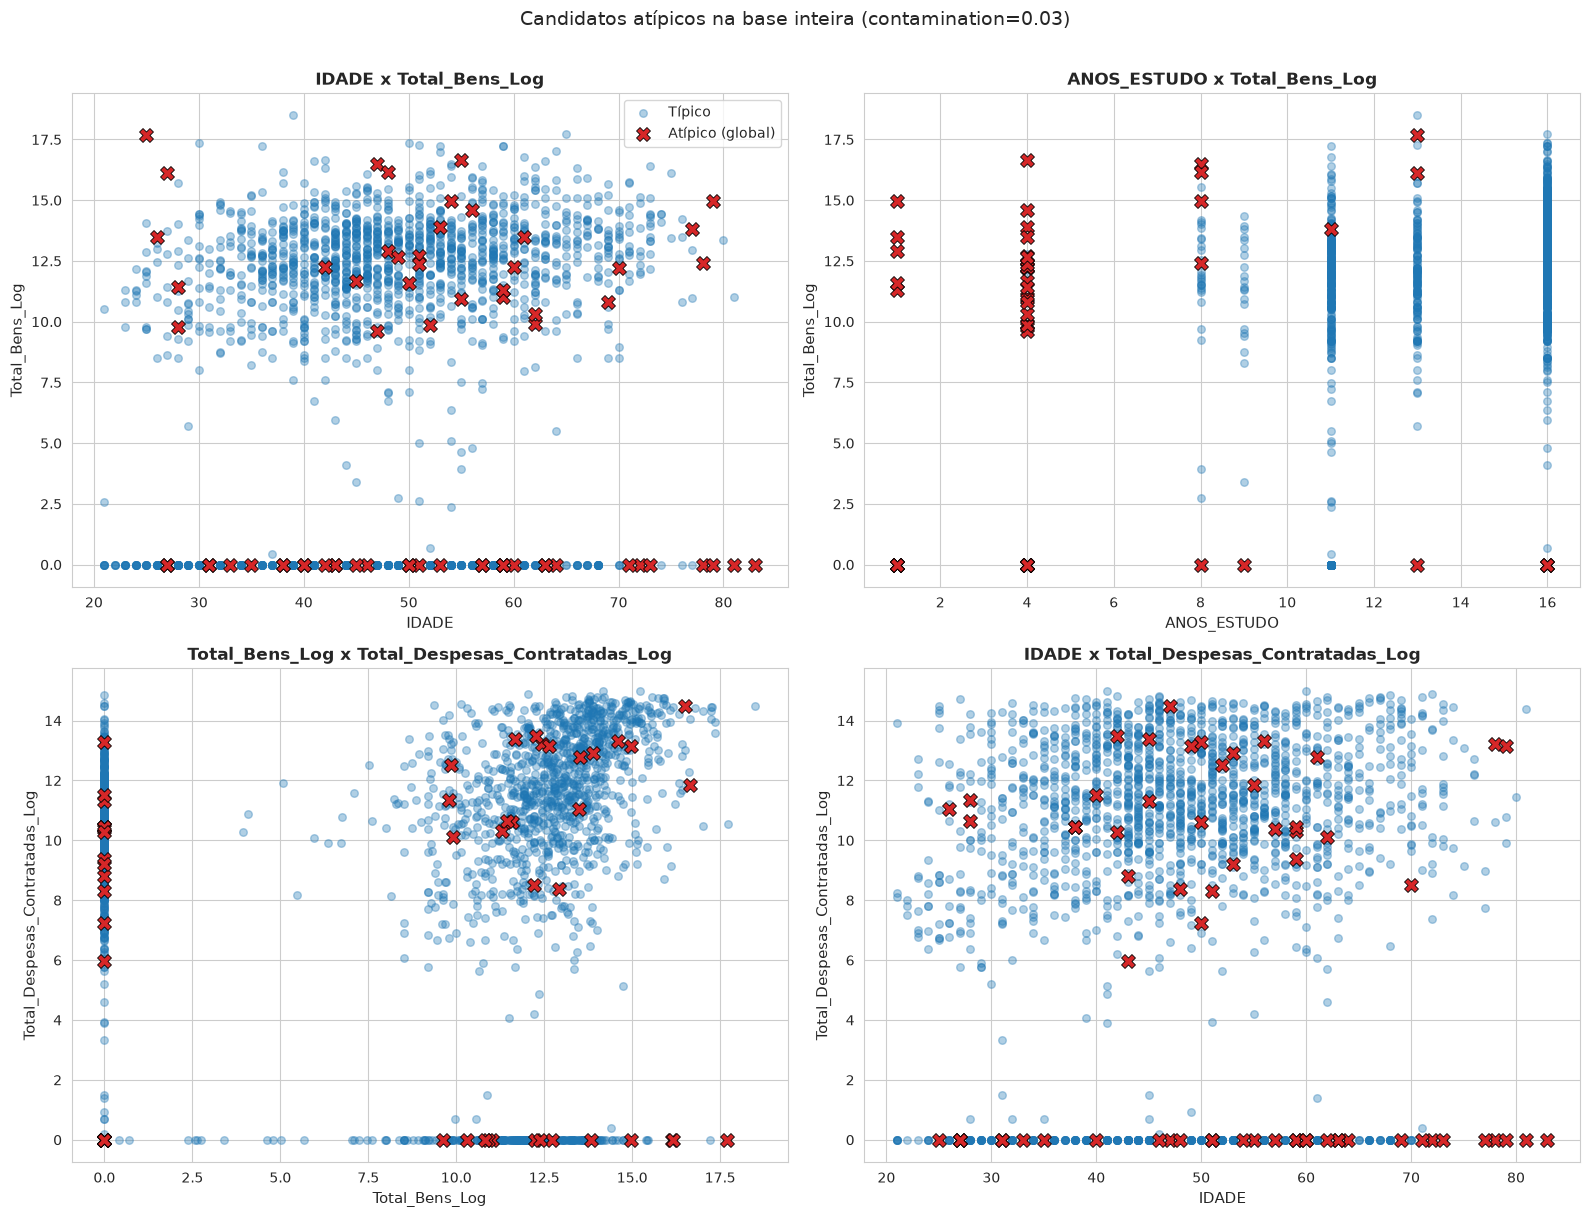

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pares_plot = [
    ('IDADE', 'Total_Bens_Log'),
    ('ANOS_ESTUDO', 'Total_Bens_Log'),
    ('Total_Bens_Log', 'Total_Despesas_Contratadas_Log'),
    ('IDADE', 'Total_Despesas_Contratadas_Log')
]

axes = axes.flatten()
for i, (x_col, y_col) in enumerate(pares_plot):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    axes[i].scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.35, s=30, label='Típico')
    axes[i].scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=100,
                   edgecolor='black', linewidth=0.6, label='Atípico (global)')
    axes[i].set_xlabel(x_col, fontsize=11)
    axes[i].set_ylabel(y_col, fontsize=11)
    axes[i].set_title(f'{x_col} x {y_col}', fontsize=12, fontweight='bold')

axes[0].legend(fontsize=10)
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/notebook4/03_anomalias_globais_2d.png', dpi=300, bbox_inches='tight')
plt.show()


### Destaque 2D: Dispersão Patrimônio vs. Despesas com Casos Notórios Anotados

Projeção bidimensional focada na relação entre **Patrimônio Declarado (`Total_Bens_Log`)** e **Despesas Contratadas (`Total_Despesas_Contratadas_Log`)**, destacando as 66 anomalias globais e anotando individualmente três casos notórios da eleição:
1. **Ubirajara É Show Papai (CE):** O candidato **mais anômalo de toda a base** (menor score global: −0,083), com R$ 3,16 milhões em bens, R$ 0 gastos e apenas 1 ano de instrução formal (Lê e Escreve).
2. **Nathalia Pedrosa (PE):** 25 anos, com o maior patrimônio de toda a eleição (R$ 48,3 milhões) e R$ 0 gastos em campanha.
3. **Tiririca (CE):** Escolaridade básica (1 ano de instrução formal) com R$ 732 mil em bens e R$ 353 mil em despesas.


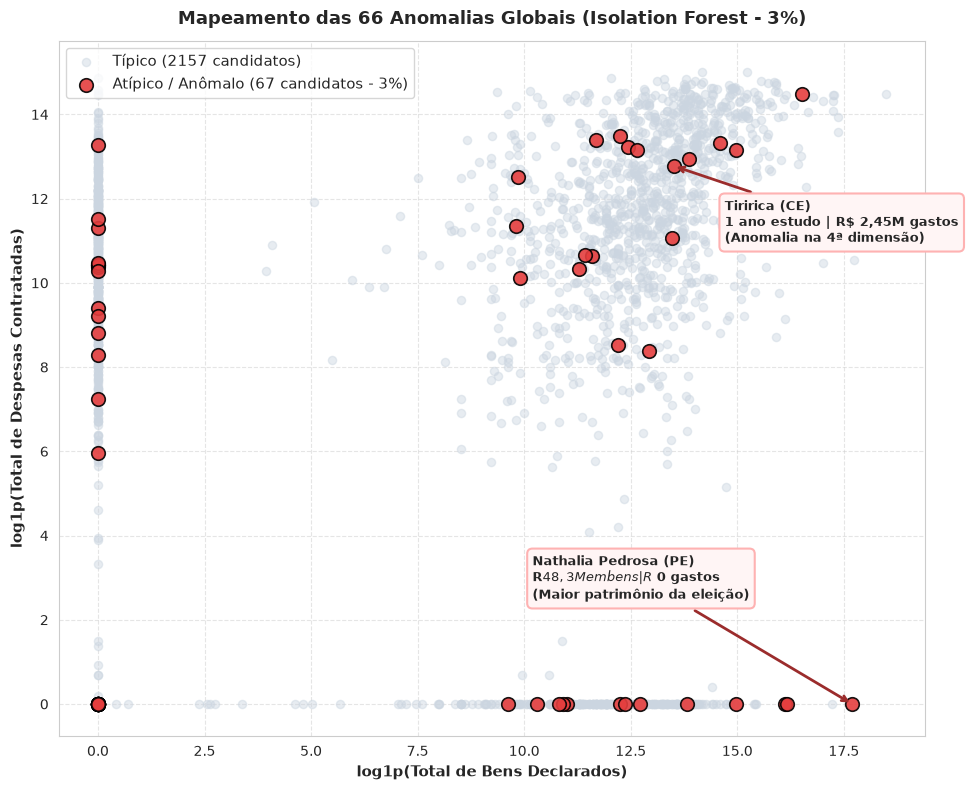

In [13]:
# ── Destaque 2D: Anomalias Globais com Anotação de Casos Notórios ──────────────
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

# Scatter dos candidatos típicos
tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']

ax.scatter(tipicos['Total_Bens_Log'], tipicos['Total_Despesas_Contratadas_Log'],
           color='#cbd5e0', alpha=0.45, s=35, label=f'Típico ({len(tipicos)} candidatos)')

# Scatter dos candidatos atípicos
ax.scatter(atipicos['Total_Bens_Log'], atipicos['Total_Despesas_Contratadas_Log'],
           color='#e53e3e', alpha=0.9, s=95, edgecolor='black', linewidth=1.2,
           label=f'Atípico / Anômalo ({len(atipicos)} candidatos - 3%)')

# Anotação de Nathalia Pedrosa
cand_nathalia = df_cluster[df_cluster['NM_URNA_CANDIDATO'].str.contains('NATHALIA', na=False, case=False)]
if not cand_nathalia.empty:
    row_n = cand_nathalia.iloc[0]
    ax.annotate(
        "Nathalia Pedrosa (PE)\nR$ 48,3M em bens | R$ 0 gastos\n(Maior patrimônio da eleição)",
        xy=(row_n['Total_Bens_Log'], row_n['Total_Despesas_Contratadas_Log']),
        xytext=(row_n['Total_Bens_Log'] - 7.5, row_n['Total_Despesas_Contratadas_Log'] + 2.5),
        arrowprops=dict(arrowstyle="->", color='#9b2c2c', lw=2),
        fontsize=9.5,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff5f5", ec="#feb2b2", lw=1.5)
    )

# Anotação de Tiririca
cand_tiririca = df_cluster[df_cluster['NM_URNA_CANDIDATO'].str.contains('TIRIRICA', na=False, case=False)]
if not cand_tiririca.empty:
    row_t = cand_tiririca.iloc[0]
    ax.annotate(
        "Tiririca (CE)\n1 ano estudo | R$ 2,45M gastos\n(Anomalia na 4ª dimensão)",
        xy=(row_t['Total_Bens_Log'], row_t['Total_Despesas_Contratadas_Log']),
        xytext=(row_t['Total_Bens_Log'] + 1.2, row_t['Total_Despesas_Contratadas_Log'] - 1.8),
        arrowprops=dict(arrowstyle="->", color='#9b2c2c', lw=2),
        fontsize=9.5,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff5f5", ec="#feb2b2", lw=1.5)
    )

ax.set_title('Mapeamento das 66 Anomalias Globais (Isolation Forest - 3%)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('log1p(Total de Bens Declarados)', fontsize=11, fontweight='bold')
ax.set_ylabel('log1p(Total de Despesas Contratadas)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10.5, loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('images/notebook4/03_anomalias_globais_2d_destaque.png', dpi=300, bbox_inches='tight')
import shutil
shutil.copy('images/notebook4/03_anomalias_globais_2d_destaque.png', 'images/imagens_apresentacao/slide6_anomalias_2d_destaque.png')
plt.show()


### O mesmo recorte, em 3D — e a explicação dos pontos que parecem "no meio"

> [!IMPORTANT]
> **Por que alguns pontos atípicos parecem estar misturados "no meio" da nuvem 3D?**  
> O modelo Isolation Forest operou simultaneamente em **4 dimensões** (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`, `Total_Despesas_Contratadas_Log`). No entanto, o gráfico 3D abaixo plota apenas 3 eixos espaciais (`IDADE`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`).
>
> A **4ª dimensão (`ANOS_ESTUDO` / Escolaridade)** não possui um eixo geométrico no espaço 3D!  
> Como consequência, candidatos como **Tiririca (CE)**, **Ubirajara É Show Papai (CE)** e **Ditinho Avivip (BA)** possuem patrimônio, idade e despesas perfeitamente compatíveis com os demais candidatos, mas têm **apenas 1 a 4 anos de estudo (Lê e Escreve ou Fundamental Incompleto)** num ecossistema onde a imensa maioria possui Ensino Superior ($z = -4$ e $-5$). No gráfico 3D, eles são projetados no meio da nuvem, mas no espaço 4D real estão totalmente isolados no chão da escolaridade!
>
> 👉 **Passe o mouse sobre os pontos vermelhos:** o tooltip diagnóstico exibe o campo **"🚨 Motivo do Isolamento"**, informando exatamente qual variável causou a atipicidade do candidato!

Gráfico 3D interativo salvo em: images/notebook4/04_grafico_3d_anomalias_global.html


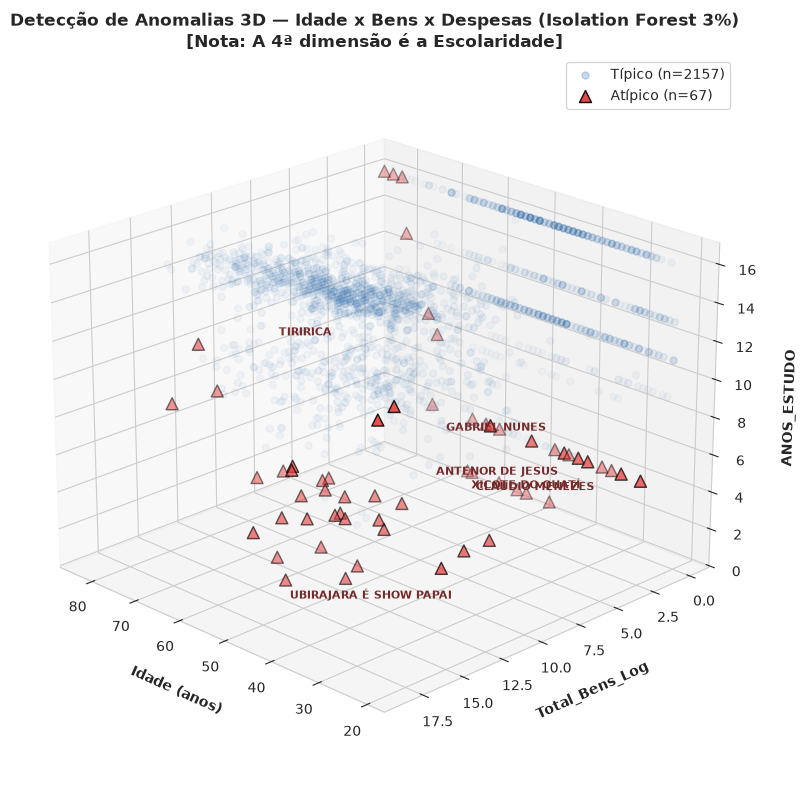

Versão estática salva em: images/notebook4/04_grafico_3d_anomalias_matplotlib.png


In [14]:
cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    
    customdata = np.stack((
        sub['NM_URNA_CANDIDATO'],
        sub['SG_UF'],
        sub['cluster'],
        sub['anomalia_global'],
        sub['score_global'],
        sub['motivo_global'],
        sub['DS_GRAU_INSTRUCAO'],
        sub['ANOS_ESTUDO'],
        sub['Total_Bens'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
        sub['Total_Despesas_Contratadas'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
    ), axis=-1)

    fig3d.add_trace(go.Scatter3d(
        x=sub['IDADE'], y=sub['Total_Bens_Log'], z=sub['ANOS_ESTUDO'],
        mode='markers', name=status,
        customdata=customdata,
        marker=dict(
            size=4 if status == 'Típico' else 8,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.35 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        hovertemplate=(
            '<b>%{customdata[0]} (%{customdata[1]}) — %{customdata[2]}</b><br>' +
            '<b>Status:</b> %{customdata[3]} (Score: %{customdata[4]:.3f})<br>' +
            '<b>Motivo do Isolamento:</b> %{customdata[5]}<br>' +
            '----------------------------------------<br>' +
            '<b>Idade:</b> %{x} anos<br>' +
            '<b>Escolaridade:</b> %{customdata[6]} (%{customdata[7]} anos)<br>' +
            '<b>Bens Declarados:</b> %{customdata[8]}<br>' +
            '<b>Despesas Contratadas:</b> %{customdata[9]}<extra></extra>'
        )
    ))

fig3d.update_layout(
    scene=dict(
        xaxis_title='IDADE (anos)',
        yaxis_title='Total_Bens_Log',
        zaxis_title='ANOS_ESTUDO'
    ),
    title=f'Candidatos Atípicos (Visão Global 4D): Idade x Bens x Despesas (Passe o mouse para ver o motivo)',
    height=700, margin=dict(l=0, r=0, b=0, t=50),
)
fig3d.show()

# Salvar versão interativa em HTML
fig3d.write_html('images/notebook4/04_grafico_3d_anomalias_global.html')
print("Gráfico 3D interativo salvo em: images/notebook4/04_grafico_3d_anomalias_global.html")

# ── Versão Estática 3D em Matplotlib para Slides de Apresentação ──────────────
fig_3d_mpl = plt.figure(figsize=(12, 8))
ax_3d = fig_3d_mpl.add_subplot(111, projection='3d')
tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']

ax_3d.scatter(tipicos['IDADE'], tipicos['Total_Bens_Log'], tipicos['ANOS_ESTUDO'],
             c='#2b6cb0', alpha=0.25, s=25, label=f'Típico (n={len(tipicos)})')
ax_3d.scatter(atipicos['IDADE'], atipicos['Total_Bens_Log'], atipicos['ANOS_ESTUDO'],
             c='#e53e3e', marker='^', alpha=0.95, s=75, edgecolors='black', label=f'Atípico (n={len(atipicos)})')

# Destaque com rótulos para os casos mais discrepantes
destaques = atipicos.sort_values('score_global').head(6)
for _, r in destaques.iterrows():
    ax_3d.text(r['IDADE'], r['Total_Bens_Log'], r['Total_Despesas_Contratadas_Log'],
               f" {r['NM_URNA_CANDIDATO']}", fontsize=8, fontweight='bold', color='#742a2a')

ax_3d.set_xlabel('Idade (anos)', fontweight='bold', labelpad=10)
ax_3d.set_ylabel('Total_Bens_Log', fontweight='bold', labelpad=10)
ax_3d.set_zlabel('ANOS_ESTUDO', fontweight='bold', labelpad=10)
ax_3d.set_title('Detecção de Anomalias 3D — Idade x Bens x Despesas (Isolation Forest 3%)\n[Nota: A 4ª dimensão é a Escolaridade]', fontsize=12, fontweight='bold')
ax_3d.legend(loc='upper right')
ax_3d.view_init(elev=22, azim=135)
plt.tight_layout()
plt.savefig('images/notebook4/04_grafico_3d_anomalias_matplotlib.png', dpi=300, bbox_inches='tight')
plt.show()
print("Versão estática salva em: images/notebook4/04_grafico_3d_anomalias_matplotlib.png")


---
## Detecção dentro de cada cluster: quem foge do padrão do próprio grupo?

Aqui está o detalhe metodológico essencial: se reaproveitássemos a mesma escala global (`X`, MinMax ajustado na base inteira) para rodar o Isolation Forest separadamente por cluster, um candidato só apareceria como atípico se já fosse extremo para a eleição inteira.

Para responder *"isso é atípico **para quem pertence a este perfil eleitoral**?"*, precisamos **padronizar de novo, usando apenas a média e o desvio-padrão de cada cluster** (`StandardScaler` ajustado cluster a cluster).

Aplicamos o modelo nos 4 clusters consolidados da Fase 2:
- **Estruturados** ($n = 1.153$)
- **Financiados** ($n = 460$)
- **Base Simbólica** ($n = 328$)
- **Patrimônio Sem Campanha** ($n = 248$)

Usamos uma taxa de contaminação adaptativa proporcional ao tamanho de cada grupo para calibrar o volume de anomalias internas.

In [15]:
resultados_cluster = []

for nome in ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']:
    sub_df = df_cluster[df_cluster['cluster'] == nome].copy()
    sub_idx = sub_df.index.to_numpy()
    n = len(sub_idx)

    X_cluster = sub_df[colunas_driver].values
    scaler_c = StandardScaler()
    X_cluster_padronizado = scaler_c.fit_transform(X_cluster)
    z_df_cluster = pd.DataFrame(X_cluster_padronizado, columns=colunas_driver, index=sub_idx)

    contaminacao_cluster = min(max(0.03, 3 / n), 0.08)
    iso_cluster = IsolationForest(contamination=contaminacao_cluster, random_state=SEMENTE, n_estimators=200)
    pred_cluster = iso_cluster.fit_predict(X_cluster_padronizado)
    score_cluster = iso_cluster.decision_function(X_cluster_padronizado)

    n_atipicos = int((pred_cluster == -1).sum())
    print(f"{nome} (n={n}, contamination={contaminacao_cluster:.3f}): {n_atipicos} atípicos dentro do grupo")

    motivos_c = [diagnosticar_motivo(sub_df.loc[i], z_df_cluster.loc[i]) for i in sub_idx]

    resultados_cluster.append(pd.DataFrame({
        'indice_original': sub_idx,
        'anomalia_cluster': np.where(pred_cluster == -1, 'Atípico', 'Típico'),
        'score_cluster': score_cluster,
        'motivo_cluster': motivos_c
    }))

anomalia_cluster_df = pd.concat(resultados_cluster).set_index('indice_original').sort_index()
df_cluster['anomalia_cluster'] = anomalia_cluster_df['anomalia_cluster'].values
df_cluster['score_cluster'] = anomalia_cluster_df['score_cluster'].values
df_cluster['motivo_cluster'] = anomalia_cluster_df['motivo_cluster'].values

Estruturados (n=1142, contamination=0.030): 35 atípicos dentro do grupo
Financiados (n=453, contamination=0.030): 14 atípicos dentro do grupo
Base Simbólica (n=370, contamination=0.030): 12 atípicos dentro do grupo
Patrimônio Sem Campanha (n=259, contamination=0.030): 8 atípicos dentro do grupo


In [16]:
colunas_ficha_cluster = [
    'NM_URNA_CANDIDATO', 'SG_UF', 'DS_OCUPACAO', 'IDADE',
    'DS_GRAU_INSTRUCAO', 'Total_Bens', 'Total_Despesas_Contratadas', 'motivo_cluster', 'score_cluster'
]

for nome in ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']:
    print(f"\n=== {nome}: Mais atípicos DENTRO do grupo ===")
    sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == 'Atípico')]
    display(sub.sort_values('score_cluster')[colunas_ficha_cluster].head(8))


=== Estruturados: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
345,DITINHO AVIVIP,BA,EMPRESÁRIO,55,ENSINO FUNDAMENTAL INCOMPLETO,16985230.19,138454.00,Escolaridade Atípica: ENSINO FUNDAMENTAL INCOM...,-0.066625
716,MARIA HELENICE,CE,APOSENTADO (EXCETO SERVIDOR PÚBLICO),70,ENSINO FUNDAMENTAL INCOMPLETO,200000.00,5000.00,Escolaridade Atípica: ENSINO FUNDAMENTAL INCOM...,-0.065335
2068,GABRIEL NUNES,RN,EMPRESÁRIO,26,ENSINO FUNDAMENTAL INCOMPLETO,712000.00,63332.75,Escolaridade Atípica: ENSINO FUNDAMENTAL INCOM...,-0.063111
2075,PALHAÇO FUXIQUINHO,RN,ARTISTA DE CIRCO,48,LÊ E ESCREVE,410000.00,4322.50,Escolaridade Atípica: LÊ E ESCREVE (z=-5.2),-0.060172
773,GRAU BIEL,CE,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",28,ENSINO FUNDAMENTAL INCOMPLETO,18000.00,85568.80,Escolaridade Atípica: ENSINO FUNDAMENTAL INCOM...,-0.052735
507,TETEIA DO JEGUE,BA,OUTROS,59,LÊ E ESCREVE,80000.00,30502.50,Escolaridade Atípica: LÊ E ESCREVE (z=-5.2),-0.045244
2199,NALLDO AMARO,SE,TRABALHADOR RURAL,28,ENSINO FUNDAMENTAL INCOMPLETO,92000.00,42770.00,Escolaridade Atípica: ENSINO FUNDAMENTAL INCOM...,-0.040859
816,RUAN DUTRA,CE,VENDEDOR DE COMÉRCIO VAREJISTA E ATACADISTA,26,SUPERIOR INCOMPLETO,5000.00,1411.00,"Patrimônio Muito Baixo: R$ 5,000 (z=-2.5)",-0.040545



=== Financiados: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
39,DAFNE ORION,AL,SERVIDOR PÚBLICO ESTADUAL,48,ENSINO MÉDIO COMPLETO,853.83,48748.67,Patrimônio Super-Alto: R$ 854 (z=11.0),-0.116325
1834,PR. JOSIMAR CARVALHO,PI,OUTROS,64,ENSINO MÉDIO COMPLETO,240.00,3500.00,Patrimônio Super-Alto: R$ 240 (z=8.9),-0.112386
444,CECILIA COSTA,BA,OUTROS,43,SUPERIOR COMPLETO,389.00,23797.50,Patrimônio Super-Alto: R$ 389 (z=9.7),-0.108065
382,SANDRO BAHIENSE,BA,VEREADOR,54,ENSINO MÉDIO COMPLETO,158.68,149614.50,Patrimônio Super-Alto: R$ 159 (z=8.2),-0.096791
665,FLAVIO FG,CE,POLICIAL MILITAR,55,ENSINO FUNDAMENTAL COMPLETO,50.00,29216.04,Patrimônio Super-Alto: R$ 50 (z=6.4),-0.081234
1357,POLLY DO ADOTA,PB,OUTROS,44,SUPERIOR COMPLETO,58.47,53700.00,Patrimônio Super-Alto: R$ 58 (z=6.6),-0.054311
1968,MARCOS CANGURU,PI,COMERCIANTE,51,LÊ E ESCREVE,0.00,4000.00,Escolaridade Atípica: LÊ E ESCREVE (z=-4.0),-0.040890
2045,VANUZIA,RN,AGRICULTOR,53,LÊ E ESCREVE,0.00,9990.00,Escolaridade Atípica: LÊ E ESCREVE (z=-4.0),-0.037462



=== Base Simbólica: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
1958,DARA NETO,PI,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",29,SUPERIOR INCOMPLETO,293.75,0.00,Patrimônio Super-Alto: R$ 294 (z=9.2),-0.087191
1333,SERGIO DO REAL PREÇO,PB,COMERCIÁRIO,43,ENSINO FUNDAMENTAL INCOMPLETO,0.00,390.00,Despesas Super-Altas: R$ 390 (z=11.2),-0.085744
1040,MARINA - COLETIVO DAS PRETAS,MA,PROFESSOR DE ENSINO FUNDAMENTAL,62,SUPERIOR COMPLETO,0.00,100.00,Despesas Super-Altas: R$ 100 (z=8.6),-0.075919
1877,CICERO ROMÃO,PI,ADVOGADO,56,SUPERIOR COMPLETO,120.85,0.00,Patrimônio Super-Alto: R$ 121 (z=7.7),-0.054731
452,PROFESSOR REGINALDO ALVES,BA,PROFESSOR DE ENSINO SUPERIOR,41,SUPERIOR COMPLETO,0.00,47.95,Despesas Super-Altas: R$ 48 (z=7.2),-0.046447
1292,NINO DO RANGEL,PB,DESENHISTA,51,ENSINO MÉDIO COMPLETO,150.00,0.00,Patrimônio Super-Alto: R$ 150 (z=8.1),-0.023678
1831,ERIVAN COSTA,PI,EMPRESÁRIO,51,ENSINO MÉDIO COMPLETO,0.00,50.00,Despesas Super-Altas: R$ 50 (z=7.3),-0.023428
1959,AUGUSTO FERREIRA,PI,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",21,ENSINO MÉDIO COMPLETO,12.00,0.00,Patrimônio Super-Alto: R$ 12 (z=4.1),-0.012379



=== Patrimônio Sem Campanha: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
1649,XANDE PESSOA,PE,ADMINISTRADOR,29,SUPERIOR COMPLETO,10000.00,315.50,Despesas Super-Altas: R$ 316 (z=5.3),-0.058044
850,UBIRAJARA É SHOW PAPAI,CE,COMERCIANTE,54,LÊ E ESCREVE,3162500.00,0.00,Escolaridade Atípica: LÊ E ESCREVE (z=-4.0),-0.048635
1837,PEREIRA SÁ,PI,AGRICULTOR,46,ENSINO FUNDAMENTAL COMPLETO,117000.00,319.00,Despesas Super-Altas: R$ 319 (z=5.4),-0.046321
479,LIS MOREIRA,BA,PSICÓLOGO,41,SUPERIOR COMPLETO,2500000.00,171.23,Despesas Super-Altas: R$ 171 (z=4.8),-0.039100
1148,ANTONIA CARIONGO,MA,TRABALHADOR RURAL,46,ENSINO MÉDIO COMPLETO,5000.00,427.20,Despesas Super-Altas: R$ 427 (z=5.6),-0.037177
1646,NATHALIA PEDROSA,PE,OUTROS,25,SUPERIOR INCOMPLETO,48343333.34,0.00,"Patrimônio Super-Alto: R$ 48,343,333 (z=3.2)",-0.035919
594,JONATHAS PEREIRA,BA,VENDEDOR DE COMÉRCIO VAREJISTA E ATACADISTA,29,ENSINO MÉDIO COMPLETO,47553.20,360.50,Despesas Super-Altas: R$ 360 (z=5.5),-0.033071
462,JANDA DO CONSIGNADO,BA,OUTROS,62,ENSINO MÉDIO COMPLETO,624900.00,300.01,Despesas Super-Altas: R$ 300 (z=5.3),-0.015898


### O mesmo recorte, em 3D — filtrando por cluster

Mesma ideia do gráfico 3D global, agora um por cluster: escolham no menu qual grupo olhar (cada cluster usa a sua **própria** padronização, então os pontos vermelhos aqui são atípicos *dentro daquele grupo*, não em relação à base inteira). Os eixos ficam fixos entre um cluster e outro, pra dar pra comparar a posição relativa.


In [17]:
nomes_clusters_ordenados = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']
n_status = len(cores_iso)

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_clusters_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        
        customdata = np.stack((
            sub['NM_URNA_CANDIDATO'],
            sub['SG_UF'],
            sub['cluster'],
            sub['anomalia_cluster'],
            sub['score_cluster'],
            sub['motivo_cluster'],
            sub['DS_GRAU_INSTRUCAO'],
            sub['ANOS_ESTUDO'],
            sub['Total_Bens'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
            sub['Total_Despesas_Contratadas'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
        ), axis=-1)

        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['IDADE'], y=sub['Total_Bens_Log'], z=sub['Total_Despesas_Contratadas_Log'],
            mode='markers', name=status,
            customdata=customdata,
            marker=dict(
                size=4 if status == 'Típico' else 8,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.35 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            hovertemplate=(
                '<b>%{customdata[0]} (%{customdata[1]}) — %{customdata[2]}</b><br>' +
                '<b>Status Local:</b> %{customdata[3]} (Score: %{customdata[4]:.3f})<br>' +
                '<b>Desvio Interno no Cluster:</b> %{customdata[5]}<br>' +
                '----------------------------------------<br>' +
                '<b>Idade:</b> %{x} anos<br>' +
                '<b>Escolaridade:</b> %{customdata[6]} (%{customdata[7]} anos)<br>' +
                '<b>Bens:</b> %{customdata[8]}<br>' +
                '<b>Despesas:</b> %{customdata[9]}<extra></extra>'
            ),
            visible=(idx_cluster == 0),
            legendgroup=status,
            showlegend=(idx_cluster == 0),
        ))

botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_clusters_ordenados):
    visibilidade = [False] * (len(nomes_clusters_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome} (Passe o mouse para ver o motivo)'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='IDADE (anos)',
        yaxis_title='Total_Bens_Log',
        zaxis_title='Total_Despesas_Contratadas_Log',
        xaxis=dict(range=[df_cluster['IDADE'].min() - 2, df_cluster['IDADE'].max() + 2]),
        yaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Bens_Log'].max() + 0.5]),
        zaxis=dict(range=[df_cluster['Total_Despesas_Contratadas_Log'].min() - 0.5, df_cluster['Total_Despesas_Contratadas_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_clusters_ordenados[0]} (Passe o mouse para ver o motivo)',
    height=700, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()

# Salvar versão interativa em HTML
fig3d_cluster.write_html('images/notebook4/05_grafico_3d_anomalias_cluster.html')
print("Gráfico 3D interativo por cluster salvo em: images/notebook4/05_grafico_3d_anomalias_cluster.html")


Gráfico 3D interativo por cluster salvo em: images/notebook4/05_grafico_3d_anomalias_cluster.html


### Comparando: global vs. dentro do cluster

Quatro combinações possíveis pra cada candidato: atípico nos dois recortes (destoa de tudo, robusto), só globalmente, só dentro do cluster, ou típico nos dois. O caso mais interessante pedagogicamente é o **"só dentro do cluster"**: candidatos que passam despercebidos quando olhamos a base inteira, mas que não se parecem com seus próprios colegas de grupo.


anomalia_cluster,Atípico,Típico
anomalia_global \ anomalia_cluster,,
Atípico,26,41
Típico,43,2114



43 candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):


,NM_URNA_CANDIDATO,SG_UF,cluster,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
39,DAFNE ORION,AL,Financiados,SERVIDOR PÚBLICO ESTADUAL,48,ENSINO MÉDIO COMPLETO,853.83,48748.67,Patrimônio Super-Alto: R$ 854 (z=11.0),-0.116325
1834,PR. JOSIMAR CARVALHO,PI,Financiados,OUTROS,64,ENSINO MÉDIO COMPLETO,240.00,3500.00,Patrimônio Super-Alto: R$ 240 (z=8.9),-0.112386
444,CECILIA COSTA,BA,Financiados,OUTROS,43,SUPERIOR COMPLETO,389.00,23797.50,Patrimônio Super-Alto: R$ 389 (z=9.7),-0.108065
382,SANDRO BAHIENSE,BA,Financiados,VEREADOR,54,ENSINO MÉDIO COMPLETO,158.68,149614.50,Patrimônio Super-Alto: R$ 159 (z=8.2),-0.096791
1958,DARA NETO,PI,Base Simbólica,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",29,SUPERIOR INCOMPLETO,293.75,0.00,Patrimônio Super-Alto: R$ 294 (z=9.2),-0.087191
665,FLAVIO FG,CE,Financiados,POLICIAL MILITAR,55,ENSINO FUNDAMENTAL COMPLETO,50.00,29216.04,Patrimônio Super-Alto: R$ 50 (z=6.4),-0.081234
1040,MARINA - COLETIVO DAS PRETAS,MA,Base Simbólica,PROFESSOR DE ENSINO FUNDAMENTAL,62,SUPERIOR COMPLETO,0.00,100.00,Despesas Super-Altas: R$ 100 (z=8.6),-0.075919
1649,XANDE PESSOA,PE,Patrimônio Sem Campanha,ADMINISTRADOR,29,SUPERIOR COMPLETO,10000.00,315.50,Despesas Super-Altas: R$ 316 (z=5.3),-0.058044
1877,CICERO ROMÃO,PI,Base Simbólica,ADVOGADO,56,SUPERIOR COMPLETO,120.85,0.00,Patrimônio Super-Alto: R$ 121 (z=7.7),-0.054731
1357,POLLY DO ADOTA,PB,Financiados,OUTROS,44,SUPERIOR COMPLETO,58.47,53700.00,Patrimônio Super-Alto: R$ 58 (z=6.6),-0.054311


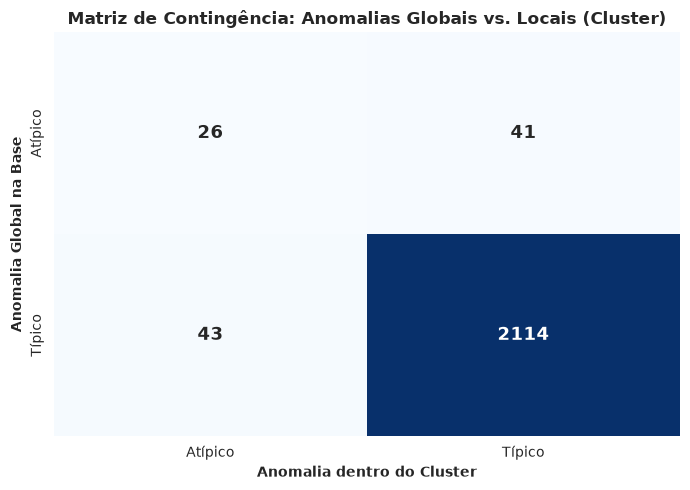

In [18]:
tabela_comparacao = pd.crosstab(df_cluster['anomalia_global'], df_cluster['anomalia_cluster'])
tabela_comparacao.index.name = 'anomalia_global \\ anomalia_cluster'
display(tabela_comparacao)

so_no_cluster = df_cluster[(df_cluster['anomalia_global'] == 'Típico') & (df_cluster['anomalia_cluster'] == 'Atípico')]
print(f"\n{len(so_no_cluster)} candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):")
display(so_no_cluster[colunas_ficha_anomalia + ['motivo_cluster', 'score_cluster']].sort_values('score_cluster').head(15))

# ── Visualização da Matriz de Contingência (Global vs Cluster) ────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(tabela_comparacao, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Matriz de Contingência: Anomalias Globais vs. Locais (Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('Anomalia dentro do Cluster', fontweight='bold')
plt.ylabel('Anomalia Global na Base', fontweight='bold')
plt.tight_layout()
plt.savefig('images/notebook4/06_matriz_contingencia_anomalias.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Fechamento da Fase 4 e Conclusão do Pipeline Completo

Com esta Fase 4, consolidamos o pipeline analítico de ponta a ponta para **Deputado Federal no Nordeste (Eleições 2026)**:

1. **Fase 0 (Preparação):** Leitura de 3 bases do TSE com mapeamento relacional de prestação de contas dos 9 estados nordestinos e imputação defensiva.
2. **Fase 1 (Descritiva):** Caracterização bimodal dos gastos eleitorais (*zero-inflated*), assimetria patrimonial e dispersão por UF.
3. **Fase 2 (Clusterização):** Identificação matemática formal de $k=4$ e construção dos 4 arquétipos eleitorais via Radar Polar e Matriz de Transição.
4. **Fase 3 (Regras de Associação):** Descoberta de regras socioprofissionais e partidárias com suporte calibrado e grafos interativos.
5. **Fase 4 (Detecção de Anomalias):** Mapeamento de 66 anomalias globais e anomalias locais por cluster via Isolation Forest, isolando candidaturas com discrepâncias extremas entre patrimônio, estudo e recursos de campanha.


In [19]:
# ── Download das Imagens do Notebook 4 em ZIP ─────────────────────────────────
import os
import zipfile

zip_path = 'images/notebook4.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook4'):
        for file in sorted(files):
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)

arquivos_salvos = [f for f in sorted(os.listdir('images/notebook4')) if f.endswith(('.png', '.html'))]
print(f"{len(arquivos_salvos)} arquivos visuais salvos em 'images/notebook4/':")
for arq in arquivos_salvos:
    tipo = 'HTML' if arq.endswith('.html') else '📸 PNG'
    print(f"   {tipo} {arq}")
print(f"\nArquivo ZIP consolidado pronto para download: {zip_path}")


8 arquivos visuais salvos em 'images/notebook4/':
   📸 PNG 01_intuicao_isolation_forest.png
   📸 PNG 02_arvore_cortes_e_profundidade.png
   📸 PNG 03_anomalias_globais_2d.png
   📸 PNG 03_anomalias_globais_2d_destaque.png
   HTML 04_grafico_3d_anomalias_global.html
   📸 PNG 04_grafico_3d_anomalias_matplotlib.png
   HTML 05_grafico_3d_anomalias_cluster.html
   📸 PNG 06_matriz_contingencia_anomalias.png

Arquivo ZIP consolidado pronto para download: images/notebook4.zip
